<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/8_Semantic_Segmentation_Pipeline_on_Pixel_wise_Grids_using_custom_Dice_Loss_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q albumentations

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:
class SegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.images[index])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path,0)

        if self.transform:

            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.float().unsqueeze(0)

        return image, mask

In [4]:
train_transform = A.Compose([

    A.Resize(256,256),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.Rotate(limit=30,p=0.5),

    A.Normalize(),

    ToTensorV2()

])

In [5]:
class DoubleConv(nn.Module):

    def __init__(self,in_channels,out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels,out_channels,3,padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels,out_channels,3,padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)

In [6]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.down1 = DoubleConv(3,64)
        self.down2 = DoubleConv(64,128)
        self.down3 = DoubleConv(128,256)
        self.down4 = DoubleConv(256,512)

        self.bottleneck = DoubleConv(512,1024)

        self.up4 = nn.ConvTranspose2d(1024,512,2,2)
        self.conv4 = DoubleConv(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,2)
        self.conv3 = DoubleConv(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,2)
        self.conv2 = DoubleConv(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,2)
        self.conv1 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        d4 = self.down4(self.pool(d3))

        b = self.bottleneck(self.pool(d4))

        u4 = self.up4(b)
        u4 = torch.cat([u4,d4],1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3,d3],1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2,d2],1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1,d1],1)
        u1 = self.conv1(u1)

        return self.final(u1)

In [7]:
class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self,pred,target):

        pred = torch.sigmoid(pred)

        pred = pred.view(-1)
        target = target.view(-1)

        smooth = 1

        intersection = (pred*target).sum()

        dice = (2*intersection + smooth)/(pred.sum()+target.sum()+smooth)

        return 1-dice

In [8]:
class BCEDiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self,pred,target):

        return self.bce(pred,target)+self.dice(pred,target)

In [10]:
# Create directories if they don't exist
!mkdir -p dataset/images
!mkdir -p dataset/masks

# If your dataset is in Google Drive, uncomment and run the following to mount your Drive
# from google.colab import drive
# drive.mount('/content/drive')

# After mounting, you can copy files from your Drive to the created directories, e.g.:
# !cp /content/drive/MyDrivename/your_images/* dataset/images/
# !cp /content/drive/MyDrivename/your_masks/* dataset/masks/

print("Directories 'dataset/images' and 'dataset/masks' created. Please upload your images and masks into these directories or copy them from Google Drive.")

Directories 'dataset/images' and 'dataset/masks' created. Please upload your images and masks into these directories or copy them from Google Drive.


In [14]:
import os

image_count = len(os.listdir('dataset/images'))
mask_count = len(os.listdir('dataset/masks'))

print(f"Images found: {image_count}")
print(f"Masks found: {mask_count}")

if image_count == 0:
    print("\n[!] The image directory is empty. Please upload your images to 'dataset/images'.")
elif image_count != mask_count:
    print("\n[!] Warning: The number of images and masks do not match!")

Images found: 0
Masks found: 0

[!] The image directory is empty. Please upload your images to 'dataset/images'.


In [15]:
import cv2
import numpy as np
import os

def generate_sample_data(num_samples=10):
    os.makedirs('dataset/images', exist_ok=True)
    os.makedirs('dataset/masks', exist_ok=True)
    for i in range(num_samples):
        # Create a random image with a circle inside
        img = np.zeros((256, 256, 3), dtype=np.uint8)
        mask = np.zeros((256, 256), dtype=np.uint8)
        cv2.circle(img, (128, 128), 50, (255, 255, 255), -1)
        cv2.circle(mask, (128, 128), 50, 1, -1)
        cv2.imwrite(f'dataset/images/img_{i}.png', img)
        cv2.imwrite(f'dataset/masks/img_{i}.png', mask)
    print(f'Generated {num_samples} sample images and masks.')

# Run this if you want to test the code with dummy data:
generate_sample_data()

Generated 10 sample images and masks.


In [16]:
train_dataset = SegmentationDataset(
    "dataset/images",
    "dataset/masks",
    train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

criterion = BCEDiceLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

epochs = 10

loss_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs,masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)

    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}")

Epoch 1: Loss=1.1731
Epoch 2: Loss=0.8783
Epoch 3: Loss=0.8402
Epoch 4: Loss=0.8031
Epoch 5: Loss=0.7609
Epoch 6: Loss=0.7224
Epoch 7: Loss=0.6852
Epoch 8: Loss=0.6517
Epoch 9: Loss=0.6180
Epoch 10: Loss=0.5886


In [18]:
def dice_score(pred,target):

    pred = torch.sigmoid(pred)

    pred = (pred>0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred*target).sum()

    return (2*intersection+1)/(pred.sum()+target.sum()+1)

In [19]:
model.eval()

image,mask = train_dataset[0]

with torch.no_grad():

    pred = model(image.unsqueeze(0).to(device))

pred = torch.sigmoid(pred)

pred = (pred>0.5).float().cpu().squeeze()

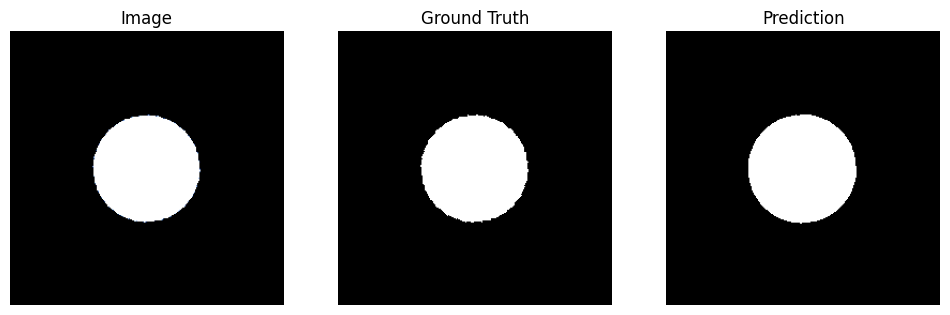

In [20]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze(),cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred,cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

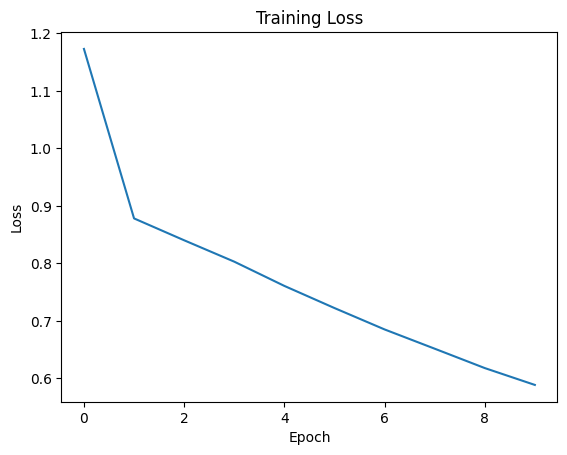

In [21]:
plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()